In [49]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageOps, ImageFilter

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from skimage.feature import hog


In [51]:
project_root = os.getcwd()

parent_dir = os.path.dirname(project_root)

training_data_path = os.path.join(parent_dir, "TrainingData")

print("Project root:", project_root)
print("Parent dir:", parent_dir)
print("TrainingData path:", training_data_path)
print("TrainingData exists:", os.path.exists(training_data_path))

Project root: C:\Users\Seiya\PycharmProjects\PythonProject\Project 4 - Seiya Genda\Code
Parent dir: C:\Users\Seiya\PycharmProjects\PythonProject\Project 4 - Seiya Genda
TrainingData path: C:\Users\Seiya\PycharmProjects\PythonProject\Project 4 - Seiya Genda\TrainingData
TrainingData exists: True


In [50]:
class NearestNeighbors:
    def __init__(
        self,
        k=3,
        image_size=(28, 28),
        random_state=42,
        use_augmentation=True,
        target_accuracy=0.95
    ):
        self.k = k
        self.image_size = image_size
        self.random_state = random_state
        self.use_augmentation = use_augmentation
        self.target_accuracy = target_accuracy

        self.X_train = None
        self.y_train = None
        self.train_files = []
        self.test_files = []
        self.model = None

    def _extract_label_from_filename(self, filename):
        base_name = os.path.basename(filename)
        match = re.match(r"(\d)", base_name)
        return int(match.group(1)) if match else None

    def _resize_to_mnist_style(self, arr, target_inner=20):
        mask = arr > 30

        if not np.any(mask):
            canvas = Image.fromarray(arr).resize(self.image_size, Image.Resampling.LANCZOS)
            return np.array(canvas).astype(np.float32) / 255.0

        ys, xs = np.where(mask)
        y_min, y_max = ys.min(), ys.max()
        x_min, x_max = xs.min(), xs.max()

        cropped = arr[y_min:y_max + 1, x_min:x_max + 1]
        h, w = cropped.shape

        if h > w:
            new_h = target_inner
            new_w = max(1, int(w * target_inner / h))
        else:
            new_w = target_inner
            new_h = max(1, int(h * target_inner / w))

        resized = Image.fromarray(cropped).resize((new_w, new_h), Image.Resampling.LANCZOS)
        canvas = Image.new("L", self.image_size, color=0)

        paste_x = (self.image_size[0] - new_w) // 2
        paste_y = (self.image_size[1] - new_h) // 2
        canvas.paste(resized, (paste_x, paste_y))

        return np.array(canvas).astype(np.float32) / 255.0

    def _center_by_mass(self, arr):
        y, x = np.indices(arr.shape)
        total = arr.sum()

        if total <= 0:
            return arr

        cx = (x * arr).sum() / total
        cy = (y * arr).sum() / total

        shift_x = int(round(arr.shape[1] / 2 - cx))
        shift_y = int(round(arr.shape[0] / 2 - cy))

        shifted = np.roll(arr, shift_y, axis=0)
        shifted = np.roll(shifted, shift_x, axis=1)

        if shift_y > 0:
            shifted[:shift_y, :] = 0
        elif shift_y < 0:
            shifted[shift_y:, :] = 0

        if shift_x > 0:
            shifted[:, :shift_x] = 0
        elif shift_x < 0:
            shifted[:, shift_x:] = 0

        return shifted

    def _trim_and_center_digit(self, img):
        img = img.convert("L")
        img = ImageOps.autocontrast(img)
        arr = np.array(img)

        if arr.mean() > 127:
            arr = 255 - arr

        arr = self._resize_to_mnist_style(arr)
        arr = self._center_by_mass(arr)
        arr = np.clip(arr, 0.0, 1.0)

        return arr.flatten().astype(np.float32)

    def _load_image(self, path):
        img = Image.open(path).convert("L")
        return self._trim_and_center_digit(img)

    def _make_features(self, X):

        X = np.array(X, dtype=np.float32)
        img = X.reshape(-1, self.image_size[1], self.image_size[0])

        row_projection = img.mean(axis=2)
        col_projection = img.mean(axis=1)

        y_grid, x_grid = np.indices(self.image_size)
        mass = img.sum(axis=(1, 2)) + 1e-6
        cx = (img * x_grid).sum(axis=(1, 2)) / mass
        cy = (img * y_grid).sum(axis=(1, 2)) / mass
        density = mass / (self.image_size[0] * self.image_size[1])
        extra = np.column_stack([cx / 28.0, cy / 28.0, density])

        hog_features = np.array([
            hog(im, orientations=8, pixels_per_cell=(7,7),
                cells_per_block=(2,2), visualize=False)
            for im in img
        ])

        features = np.hstack([X, row_projection, col_projection, extra, hog_features])
        return features.astype(np.float32)

    def _augment_array(self, X, y):
        if not self.use_augmentation:
            return X, y

        X_aug = [X]
        y_aug = [y]
        images = X.reshape(-1, self.image_size[1], self.image_size[0])

        for dy, dx in [(-2,-2),(-2,0),(-2,2),(0,-2),(0,2),(2,-2),(2,0),(2,2),(-1,0),(1,0),(0,-1),(0,1)]:
            shifted = np.roll(images, shift=(dy, dx), axis=(1, 2))
            if dy > 0: shifted[:, :dy, :] = 0
            elif dy < 0: shifted[:, dy:, :] = 0
            if dx > 0: shifted[:, :, :dx] = 0
            elif dx < 0: shifted[:, :, dx:] = 0
            X_aug.append(shifted.reshape(len(X), -1))
            y_aug.append(y)

        from scipy.ndimage import gaussian_filter
        blurred = gaussian_filter(images, sigma=(0, 0.7, 0.7))
        X_aug.append(blurred.reshape(len(X), -1))
        y_aug.append(y)

        noise = images + np.random.normal(0, 0.03, images.shape)
        noise = np.clip(noise, 0, 1)
        X_aug.append(noise.reshape(len(X), -1))
        y_aug.append(y)

        X_final = np.vstack(X_aug).astype(np.float32)
        y_final = np.concatenate(y_aug).astype(np.int32)
        return X_final, y_final

    def load_data(self, folder_path, train_ratio=0.8):
        if not os.path.exists(folder_path):
            raise FileNotFoundError(f"Path not found: {folder_path}")

        X, y, files = [], [], []

        for file_name in sorted(os.listdir(folder_path)):
            if not file_name.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            if file_name.startswith("._"):
                continue

            full_path = os.path.join(folder_path, file_name)
            label = self._extract_label_from_filename(file_name)
            if label is None:
                continue

            X.append(self._load_image(full_path))
            y.append(label)
            files.append(full_path)

        X = np.array(X, dtype=np.float32)
        y = np.array(y, dtype=np.int32)

        if len(X) == 0:
            raise ValueError("No valid image files were found.")

        rng = np.random.default_rng(self.random_state)
        indices = rng.permutation(len(X))

        X = X[indices]
        y = y[indices]
        files = [files[i] for i in indices]

        split = int(len(X) * train_ratio)

        self.X_train = X[:split]
        self.y_train = y[:split]
        self.train_files = files[:split]
        self.test_files = files[split:]

        return X[:split], y[:split], X[split:], y[split:]

    def fit(self, X, y):
        X = np.array(X, dtype=np.float32)
        y = np.array(y, dtype=np.int32)

        X_aug, y_aug = self._augment_array(X, y)
        features = self._make_features(X_aug)

        self.model = KNeighborsClassifier(
            n_neighbors=self.k,
            weights="distance",
            algorithm="auto",
            metric="manhattan",
            n_jobs=-1
        )

        self.model.fit(features, y_aug)

        self.X_train = X
        self.y_train = y

    def predict(self, X):
        if self.model is None:
            raise ValueError("Model is not trained. Run fit() first.")

        X = np.array(X, dtype=np.float32)
        features = self._make_features(X)

        return self.model.predict(features).astype(np.int32)

    def score(self, X, y):
        y = np.array(y, dtype=np.int32)
        return accuracy_score(y, self.predict(X))

    def tune_k(self, candidate_k_values, X_val, y_val):
        best_k, best_acc = None, -1

        original_train = self.X_train.copy()
        original_labels = self.y_train.copy()

        for k in candidate_k_values:
            self.k = k
            self.fit(original_train, original_labels)
            acc = self.score(X_val, y_val)
            print(f"k={k} -> {acc * 100:.2f}%")

            if acc > best_acc:
                best_acc = acc
                best_k = k

        self.k = best_k
        self.fit(original_train, original_labels)

        print(f"Best k: {best_k}, Best accuracy: {best_acc * 100:.2f}%")

        return best_k, best_acc

    def print_results(self, X, y, files):
        preds = self.predict(X)
        for i in range(min(20, len(X))):
            status = "OK" if preds[i] == y[i] else "NG"
            print(f"[{status}] File: {os.path.basename(files[i])} | Pred: {preds[i]} | True: {y[i]}")

        print("Confusion matrix:")
        print(confusion_matrix(y, preds))

    def show_image(self, X, y, index=0):
        img = np.array(X[index], dtype=np.float32).reshape(self.image_size)
        plt.imshow(img, cmap="gray")
        plt.title(f"Label: {y[index]}")
        plt.axis("off")
        plt.show()

    def show_predictions(self, X, y, count=10):
        X = np.array(X, dtype=np.float32)
        y = np.array(y, dtype=np.int32)
        preds = self.predict(X)
        count = min(count, len(X))

        cols = 5
        rows = (count + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(12, 2.5 * rows))
        axes = axes.flatten()

        for i in range(count):
            axes[i].imshow(X[i].reshape(self.image_size), cmap="gray")
            color = "black" if preds[i] == y[i] else "red"
            axes[i].set_title(f"T:{y[i]} / P:{preds[i]}", color=color)
            axes[i].axis("off")

        for i in range(count, len(axes)):
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()


In [52]:
model = NearestNeighbors(k=3, random_state=42)

X_train, y_train, X_test, y_test = model.load_data(training_data_path)

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (109, 784)
Training labels shape: (109,)
Test data shape: (28, 784)
Test labels shape: (28,)


In [53]:
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


In [54]:
candidate_k_values = [1, 2, 3, 4, 5, 7, 10, 15]
best_k, best_acc = model.tune_k(candidate_k_values, X_test, y_test)

k=1 -> 82.14%
k=2 -> 82.14%
k=3 -> 82.14%
k=4 -> 82.14%
k=5 -> 85.71%
k=7 -> 85.71%
k=10 -> 89.29%
k=15 -> 92.86%
Best k: 15, Best accuracy: 92.86%


In [55]:
accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 92.86%


In [56]:
predictions = model.predict(X_test)

print("First 20 predictions:", predictions[:20])
print("First 20 true labels:", y_test[:20])

First 20 predictions: [3 7 8 4 2 3 4 5 2 5 3 3 0 7 9 0 4 2 7 1]
First 20 true labels: [3 7 8 4 2 2 4 5 2 5 3 3 0 7 9 0 9 2 7 1]


In [57]:
model.print_results(X_test, y_test, model.test_files)

[OK] File: 3-test-2.png | Pred: 3 | True: 3
[OK] File: 7-test-2.png | Pred: 7 | True: 7
[OK] File: 8Solomon.png | Pred: 8 | True: 8
[OK] File: 444Nathan.png | Pred: 4 | True: 4
[OK] File: 2-test-5.png | Pred: 2 | True: 2
[NG] File: 2-test-1.png | Pred: 3 | True: 2
[OK] File: 4-test-2.png | Pred: 4 | True: 4
[OK] File: 5-test-4.png | Pred: 5 | True: 5
[OK] File: 2-test-6.png | Pred: 2 | True: 2
[OK] File: 5-test-7.png | Pred: 5 | True: 5
[OK] File: 33Nathan.png | Pred: 3 | True: 3
[OK] File: 3-test-7.png | Pred: 3 | True: 3
[OK] File: 0-test-7.png | Pred: 0 | True: 0
[OK] File: 7-test-5.png | Pred: 7 | True: 7
[OK] File: 9-test-8.png | Pred: 9 | True: 9
[OK] File: 00Nathan.png | Pred: 0 | True: 0
[NG] File: 9-test-3.png | Pred: 4 | True: 9
[OK] File: 2Nathan.png | Pred: 2 | True: 2
[OK] File: 7Solomon.png | Pred: 7 | True: 7
[OK] File: 1-test.png | Pred: 1 | True: 1
Confusion matrix:
[[2 0 0 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0 0 0]
 [0 0 4 1 0 0 0 0 0 0]
 [0 0 0 4 0 0 0 0 0 0]
 [0 0 0 0 3 

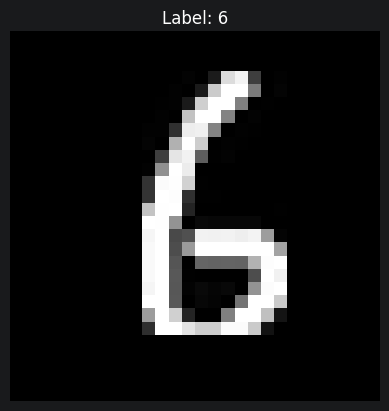

In [58]:
model.show_image(X_train, y_train, index=0)

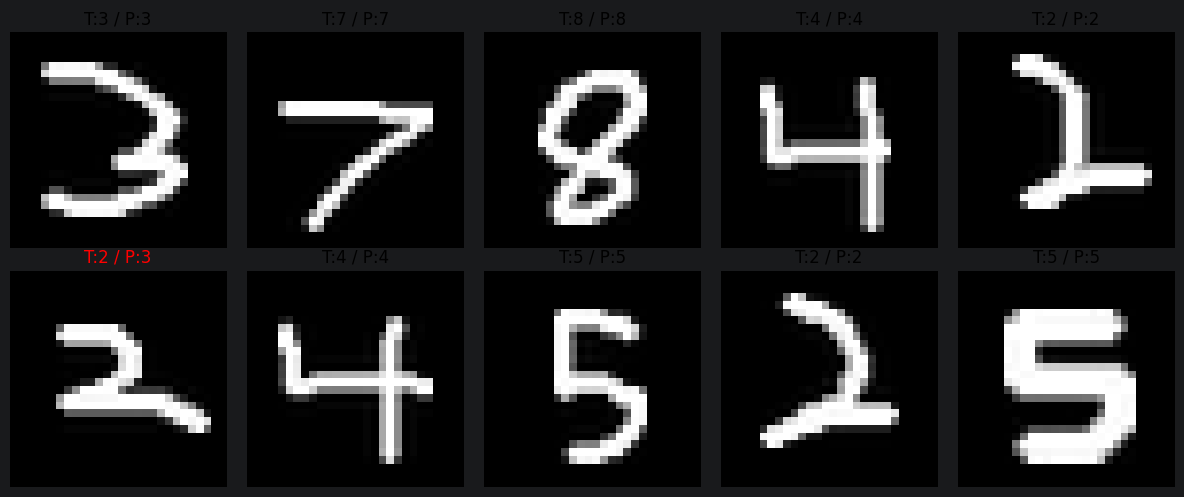

In [59]:
model.show_predictions(X_test, y_test, count=10)

In [60]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X_mnist = mnist.data.astype(np.float32) / 255.0
y_mnist = mnist.target.astype(np.int32)

X_mnist_train, X_mnist_test, y_mnist_train, y_mnist_test = train_test_split(
    X_mnist, y_mnist, test_size=10000, random_state=42
)

print("Train:", X_mnist_train.shape)
print("Test: ", X_mnist_test.shape)

Train: (60000, 784)
Test:  (10000, 784)


In [61]:
mnist_model = NearestNeighbors(k=3)
mnist_model.fit(X_mnist_train, y_mnist_train)

mnist_acc = mnist_model.score(X_mnist_test, y_mnist_test)
print(f"Accuracy: {mnist_acc * 100:.2f}%")

Accuracy: 98.18%


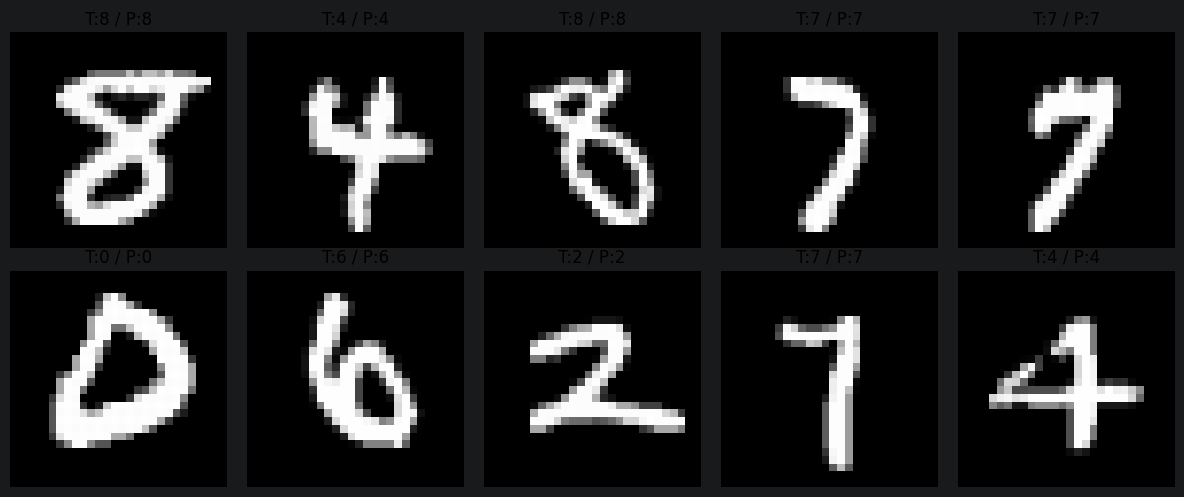

In [62]:
mnist_model.show_predictions(X_mnist_test, y_mnist_test, count=10)